<div style="text-align: center;">

# Robotics and its Application (AI352) | Lab 7

## Inverse Dynamics Control & Simulation

---

**Student Name:** *Naishadh Rana*

**Roll No:** U23CS014

---

</div>

## Part A: Lagrange-Euler Inverse Dynamics (Time-Varying Trajectory)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Part A Parameters
L1 = 1.0; L2 = 1.0
m1 = 4.0; m2 = 2.0
fc = 1.5; v = 0.3
g = 9.81

# Helper Trajectory functions
def theta1_traj(t):     return (np.pi/4) * (1 - np.cos(np.pi * t / 5))
def dtheta1_traj(t):    return (np.pi**2 / 20) * np.sin(np.pi * t / 5)
def ddtheta1_traj(t):   return (np.pi**3 / 100) * np.cos(np.pi * t / 5)

def theta2_traj(t):     return (np.pi/4) * np.sin(np.pi * t / 5)
def dtheta2_traj(t):    return (np.pi**2 / 20) * np.cos(np.pi * t / 5)
def ddtheta2_traj(t):   return -(np.pi**3 / 100) * np.sin(np.pi * t / 5)

In [13]:
def compute_dynamics_partA(th1, dth1, ddth1, th2, dth2, ddth2):
    # Determine the inertia matrix M
    M11 = (m1+m2)*(L1**2) + m2*(L2**2) + 2*m2*L1*L2*np.cos(th2)
    M12 = m2*(L2**2) + m2*L1*L2*np.cos(th2)
    M21 = M12
    M22 = m2*(L2**2)
    M = np.array([[M11, M12], [M21, M22]])
    
    # Coriolis/Centrifugal V
    h = -m2*L1*L2*np.sin(th2)
    V1 = h*(2*dth1*dth2 + dth2**2)
    V2 = -h*(dth1**2)
    V = np.array([V1, V2])
    
    # Gravity G
    G1 = (m1+m2)*g*L1*np.cos(th1) + m2*g*L2*np.cos(th1+th2)
    G2 = m2*g*L2*np.cos(th1+th2)
    G = np.array([G1, G2])
    
    # Friction F
    F1 = fc * np.sign(dth1) + v * dth1 if dth1 != 0 else 0
    F2 = fc * np.sign(dth2) + v * dth2 if dth2 != 0 else 0
    F = np.array([F1, F2])
    
    accel = np.array([ddth1, ddth2])
    inertia_term = M.dot(accel)
    tau = inertia_term + V + G + F
    return tau, inertia_term, G

In [14]:
t_vals = np.linspace(0, 5, 500)
th1_vals, dth1_vals, ddth1_vals = theta1_traj(t_vals), dtheta1_traj(t_vals), ddtheta1_traj(t_vals)
th2_vals, dth2_vals, ddth2_vals = theta2_traj(t_vals), dtheta2_traj(t_vals), ddtheta2_traj(t_vals)

tau1_arr, tau2_arr = [], []
inertia1_arr, inertia2_arr = [], []
G1_arr, G2_arr = [], []
path_x, path_y = [], []

for i in range(len(t_vals)):
    tau, inertia, G = compute_dynamics_partA(th1_vals[i], dth1_vals[i], ddth1_vals[i], 
                                             th2_vals[i], dth2_vals[i], ddth2_vals[i])
    tau1_arr.append(tau[0])
    tau2_arr.append(tau[1])
    inertia1_arr.append(inertia[0])
    inertia2_arr.append(inertia[1])
    G1_arr.append(G[0])
    G2_arr.append(G[1])
    
    # End-effector positions
    x = L1*np.cos(th1_vals[i]) + L2*np.cos(th1_vals[i]+th2_vals[i])
    y = L1*np.sin(th1_vals[i]) + L2*np.sin(th1_vals[i]+th2_vals[i])
    path_x.append(x)
    path_y.append(y)

tau1_arr = np.array(tau1_arr); tau2_arr = np.array(tau2_arr)
inertia1_arr = np.array(inertia1_arr); inertia2_arr = np.array(inertia2_arr)
G1_arr = np.array(G1_arr); G2_arr = np.array(G2_arr)

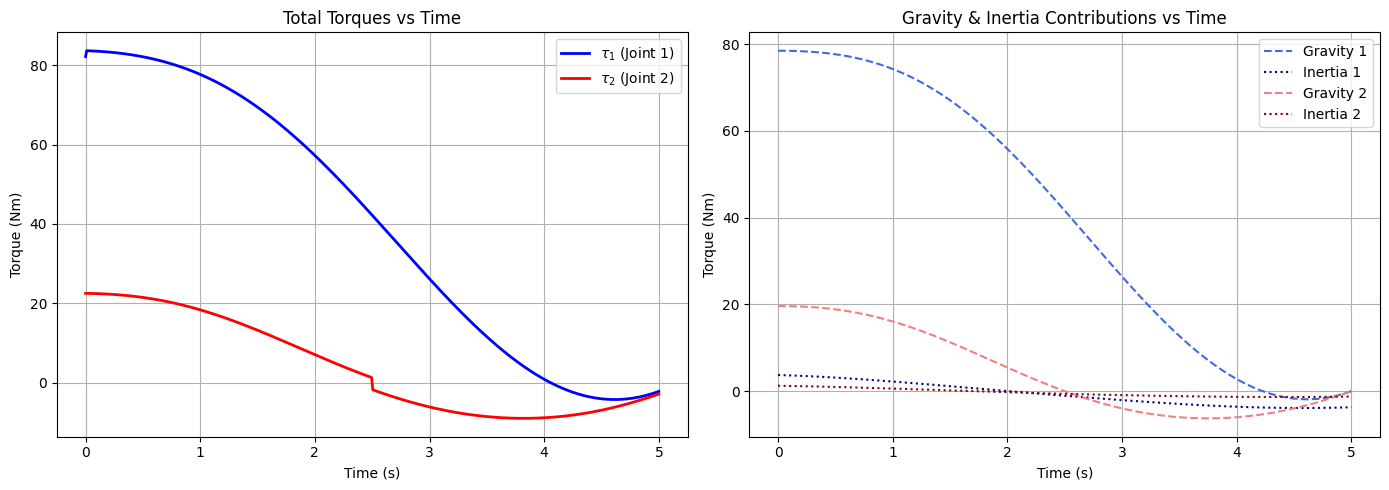

In [15]:
# Visualization of Torques and Contributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(t_vals, tau1_arr, label=r'$\tau_1$ (Joint 1)', color='blue', linewidth=2)
ax1.plot(t_vals, tau2_arr, label=r'$\tau_2$ (Joint 2)', color='red', linewidth=2)
ax1.set_title('Total Torques vs Time')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Torque (Nm)')
ax1.grid()
ax1.legend()

ax2.plot(t_vals, G1_arr, '--', label='Gravity 1', color='royalblue')
ax2.plot(t_vals, inertia1_arr, ':', label='Inertia 1', color='navy')
ax2.plot(t_vals, G2_arr, '--', label='Gravity 2', color='lightcoral')
ax2.plot(t_vals, inertia2_arr, ':', label='Inertia 2', color='darkred')
ax2.set_title('Gravity & Inertia Contributions vs Time')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Torque (Nm)')
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.show()

In [16]:
# 2D Animation of Robot Arm Moving
fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
ax_anim.set_xlim(-1, 3); ax_anim.set_ylim(-1, 3)
ax_anim.set_aspect('equal')
ax_anim.grid()
line, = ax_anim.plot([], [], 'o-', lw=4, markersize=8)
path_plot, = ax_anim.plot([], [], 'r--', alpha=0.5)

def update(frame):
    i = frame * 5 # skip frames for faster animation
    if i >= len(t_vals): i = len(t_vals)-1
    th1 = th1_vals[i]; th2 = th2_vals[i]
    x0, y0 = 0, 0
    x1 = L1 * np.cos(th1)
    y1 = L1 * np.sin(th1)
    x2 = x1 + L2 * np.cos(th1+th2)
    y2 = y1 + L2 * np.sin(th1+th2)
    line.set_data([x0, x1, x2], [y0, y1, y2])
    path_plot.set_data(path_x[:i+1], path_y[:i+1])
    return line, path_plot

ani = animation.FuncAnimation(fig_anim, update, frames=100, interval=50, blit=True)
plt.close(fig_anim)
HTML(ani.to_jshtml())

## Part B: Resolved-Rate Control (Lagrange-Euler)

In [17]:
from numpy.linalg import inv
# Robot Parameters & Setup
w = 0.05
t_thick = 0.05
rho = 7806

L1_b = 1.0
L2_b = 0.5
m1_b = rho * L1_b * w * t_thick
m2_b = rho * L2_b * w * t_thick

# Mass properties formulas
I_z1 = (m1_b / 12) * (L1_b**2 + w**2)
I_z2 = (m2_b / 12) * (L2_b**2 + w**2)
lc1 = L1_b / 2
lc2 = L2_b / 2

# Initial State
theta1_0 = np.radians(10)
theta2_0 = np.radians(90)

print(f"m1={m1_b:.3f} kg, I_z1={I_z1:.4f} kg·m^2")
print(f"m2={m2_b:.3f} kg, I_z2={I_z2:.4f} kg·m^2")

m1=19.515 kg, I_z1=1.6303 kg·m^2
m2=9.758 kg, I_z2=0.2053 kg·m^2


In [18]:
def compute_dynamics_partB(th1, dth1, ddth1, th2, dth2, ddth2, g_val):
    M11 = m1_b*lc1**2 + I_z1 + m2_b*(L1_b**2 + lc2**2 + 2*L1_b*lc2*np.cos(th2)) + I_z2
    M12 = m2_b*(lc2**2 + L1_b*lc2*np.cos(th2)) + I_z2
    M21 = M12
    M22 = m2_b*lc2**2 + I_z2
    M = np.array([[M11, M12], [M21, M22]])
    
    h = -m2_b*L1_b*lc2*np.sin(th2)
    V1 = h*(2*dth1*dth2 + dth2**2)
    V2 = -h*(dth1**2)
    V = np.array([V1, V2])
    
    G1 = (m1_b*lc1 + m2_b*L1_b)*g_val*np.cos(th1) + m2_b*lc2*g_val*np.cos(th1+th2)
    G2 = m2_b*lc2*g_val*np.cos(th1+th2)
    G = np.array([G1, G2])
    
    accel = np.array([ddth1, ddth2])
    tau = M.dot(accel) + V + G
    return tau

In [19]:
def simulate_partB(gravity_val):
    dt = 0.01
    steps = int(1.0 / dt) + 1
    t_sim = np.linspace(0, 1.0, steps)
    
    Th1 = np.zeros(steps); Th2 = np.zeros(steps)
    dTh1 = np.zeros(steps); dTh2 = np.zeros(steps)
    ddTh1 = np.zeros(steps); ddTh2 = np.zeros(steps)
    Tau1 = np.zeros(steps); Tau2 = np.zeros(steps)
    x_cart = np.zeros(steps); y_cart = np.zeros(steps)
    
    Th1[0] = theta1_0
    Th2[0] = theta2_0
    Velocity_X = np.array([[0.0], [0.5]]) # Constant Cartesian velocity
    
    for i in range(steps):
        th1 = Th1[i]; th2 = Th2[i]
        x_cart[i] = L1_b*np.cos(th1) + L2_b*np.cos(th1+th2)
        y_cart[i] = L1_b*np.sin(th1) + L2_b*np.sin(th1+th2)
        
        # 1. Jacobian
        J11 = -L1_b*np.sin(th1) - L2_b*np.sin(th1+th2)
        J12 = -L2_b*np.sin(th1+th2)
        J21 = L1_b*np.cos(th1) + L2_b*np.cos(th1+th2)
        J22 = L2_b*np.cos(th1+th2)
        J = np.array([[J11, J12], [J21, J22]])
        
        # 2. Resolved Rate (robust near singularity)
        det_J = np.linalg.det(J)
        if abs(det_J) < 1e-4:
            dTh = np.linalg.pinv(J).dot(Velocity_X).flatten()
        else:
            dTh = inv(J).dot(Velocity_X).flatten()
        dTh1[i] = dTh[0]; dTh2[i] = dTh[1]
        
        # Update Theta for next step
        if i < steps - 1:
            Th1[i+1] = Th1[i] + dTh1[i]*dt
            Th2[i+1] = Th2[i] + dTh2[i]*dt
            
        # 3. Numerical diff for accelerations
        if i > 0:
            ddTh1[i] = (dTh1[i] - dTh1[i-1]) / dt
            ddTh2[i] = (dTh2[i] - dTh2[i-1]) / dt
            
        # 4. Inverse Dynamics
        tau = compute_dynamics_partB(th1, dTh1[i], ddTh1[i], th2, dTh2[i], ddTh2[i], gravity_val)
        Tau1[i] = tau[0]; Tau2[i] = tau[1]
    
    # Optional smoothing for first step acceleration spike due to numerical differentiation
    ddTh1[0] = ddTh1[1]; ddTh2[0] = ddTh2[1]
    Tau1[0] = Tau1[1]; Tau2[0] = Tau2[1]
    
    return t_sim, Th1, Th2, dTh1, dTh2, ddTh1, ddTh2, Tau1, Tau2, x_cart, y_cart

# Case A: g = 0
res_A = simulate_partB(0.0)
# Case B: g = 9.81
res_B = simulate_partB(9.81)

Plotting Case A (Gravity Off):


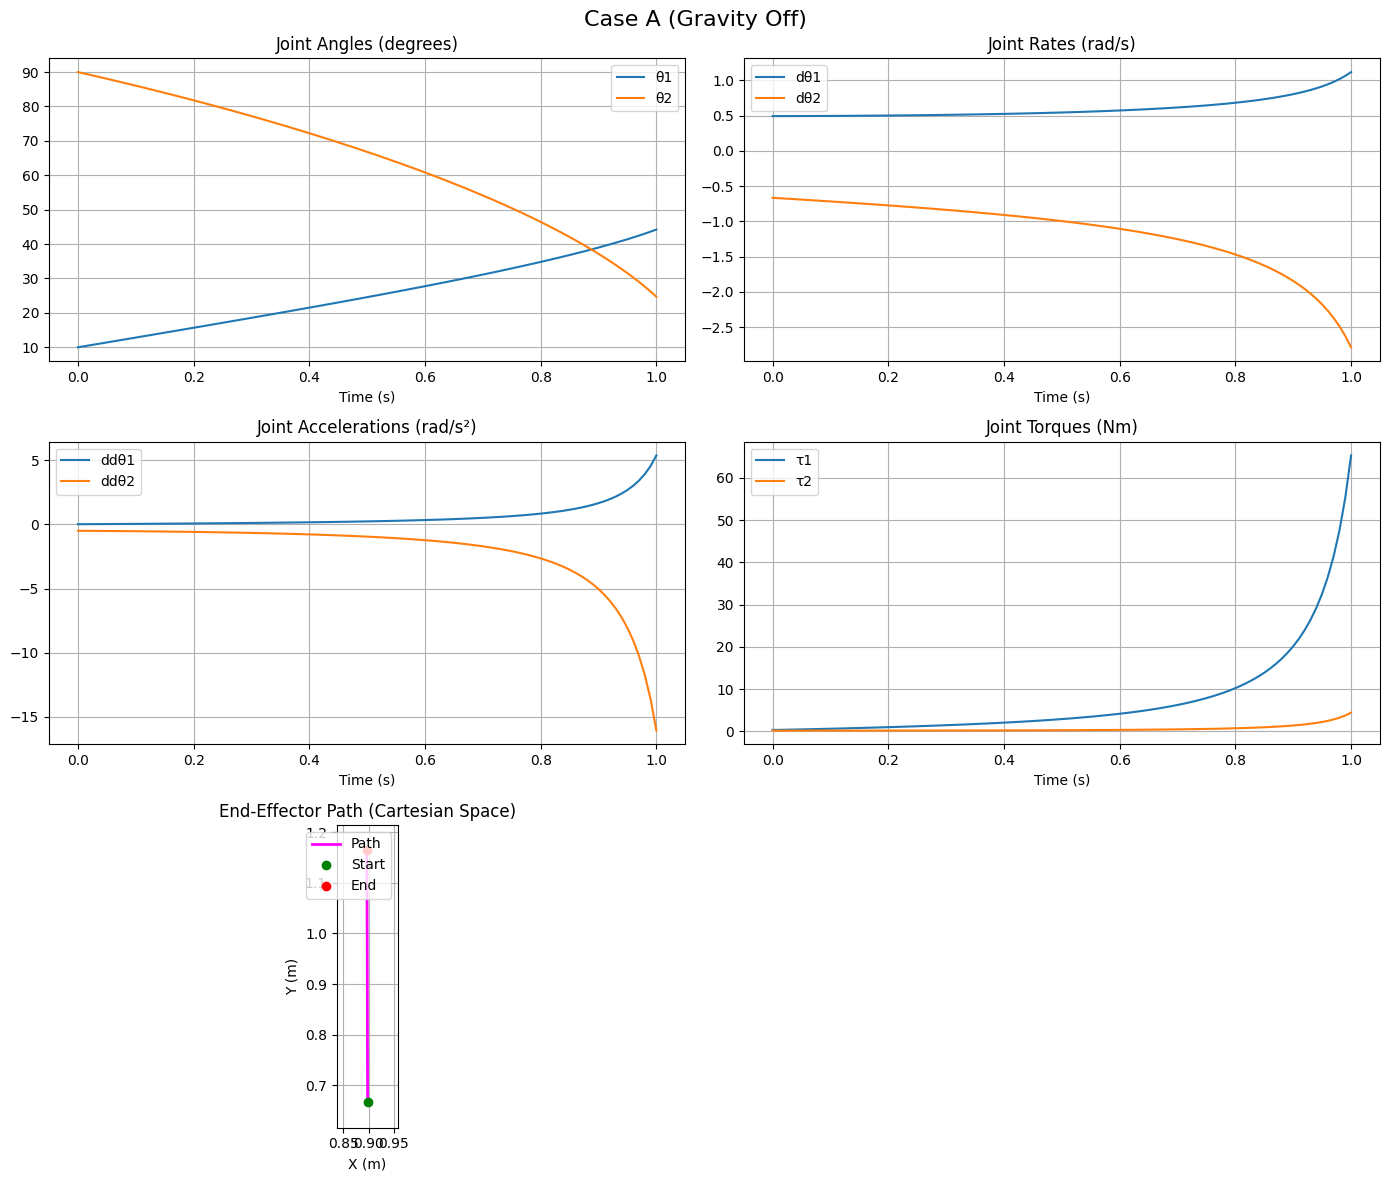

--------------------------------------------------
Plotting Case B (Gravity On):


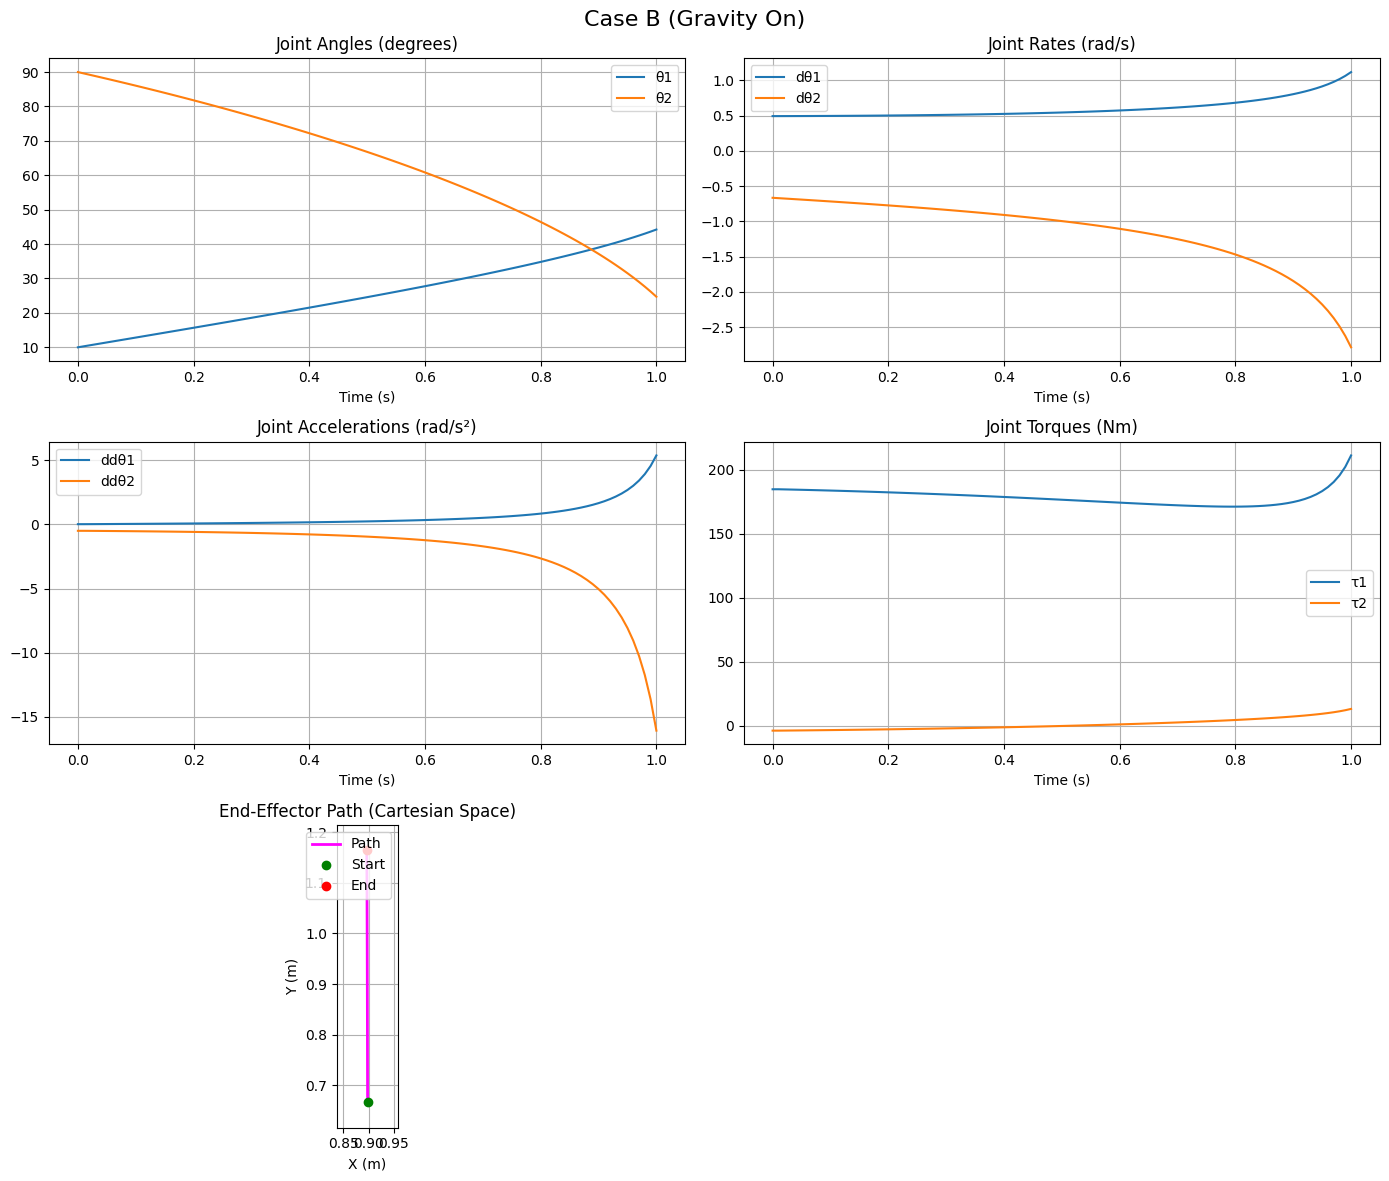

In [20]:
def plot_results(res, case_name):
    t_sim, Th1, Th2, dTh1, dTh2, ddTh1, ddTh2, Tau1, Tau2, x_c, y_c = res
    fig, axs = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(f"Case {case_name}", fontsize=16)
    
    # 1. Joint Angles
    axs[0,0].plot(t_sim, np.degrees(Th1), label='θ1')
    axs[0,0].plot(t_sim, np.degrees(Th2), label='θ2')
    axs[0,0].set_title('Joint Angles (degrees)')
    axs[0,0].set_xlabel('Time (s)'); axs[0,0].legend(); axs[0,0].grid()
    
    # 2. Joint Rates
    axs[0,1].plot(t_sim, dTh1, label='dθ1')
    axs[0,1].plot(t_sim, dTh2, label='dθ2')
    axs[0,1].set_title('Joint Rates (rad/s)')
    axs[0,1].set_xlabel('Time (s)'); axs[0,1].legend(); axs[0,1].grid()
    
    # 3. Joint Accelerations
    axs[1,0].plot(t_sim, ddTh1, label='ddθ1')
    axs[1,0].plot(t_sim, ddTh2, label='ddθ2')
    axs[1,0].set_title('Joint Accelerations (rad/s²)')
    axs[1,0].set_xlabel('Time (s)'); axs[1,0].legend(); axs[1,0].grid()
    
    # 4. Joint Torques
    axs[1,1].plot(t_sim, Tau1, label='τ1')
    axs[1,1].plot(t_sim, Tau2, label='τ2')
    axs[1,1].set_title('Joint Torques (Nm)')
    axs[1,1].set_xlabel('Time (s)'); axs[1,1].legend(); axs[1,1].grid()
    
    # 5. End-Effector Path
    axs[2,0].plot(x_c, y_c, color='magenta', linewidth=2, label='Path', zorder=3)
    axs[2,0].set_title('End-Effector Path (Cartesian Space)')
    axs[2,0].set_xlabel('X (m)'); axs[2,0].set_ylabel('Y (m)')
    axs[2,0].plot(x_c[0], y_c[0], 'go', label='Start', zorder=4)
    axs[2,0].plot(x_c[-1], y_c[-1], 'ro', label='End', zorder=4)
    
    # Keep the path visible even when X variation is very small (nearly vertical trajectory).
    x_min, x_max = np.min(x_c), np.max(x_c)
    y_min, y_max = np.min(y_c), np.max(y_c)
    x_span = max(x_max - x_min, 0.1)
    y_span = max(y_max - y_min, 0.1)
    x_mid = 0.5 * (x_min + x_max)
    y_mid = 0.5 * (y_min + y_max)
    axs[2,0].set_xlim(x_mid - 0.6 * x_span, x_mid + 0.6 * x_span)
    axs[2,0].set_ylim(y_mid - 0.6 * y_span, y_mid + 0.6 * y_span)
    
    axs[2,0].legend(); axs[2,0].grid(); axs[2,0].set_aspect('equal')
    
    axs[2,1].axis('off') # Empty
    plt.tight_layout()
    plt.show()

print("Plotting Case A (Gravity Off):")
plot_results(res_A, "A (Gravity Off)")
print("--------------------------------------------------")
print("Plotting Case B (Gravity On):")
plot_results(res_B, "B (Gravity On)")